# =============================================================================
# IMAGE CAPTIONING — FIXED VERSION
# Key fixes vs original:
#   1. Stop-word removal REMOVED  → model learns full grammar
#   2. VGG16 now uses FC2 layer   → 4096-dim rich features (not 512-dim avg pool)
#   3. Dropout added everywhere   → prevents overfitting
#   4. Padding changed to 'pre'   → correct for causal language generation
#   5. BLEU evaluation fixed      → correct [[ref_tokens, ...]] structure
#   6. Beam search decoding       → better captions than greedy argmax
#   7. Syntax error fixed         → indentation on print(actual[0])
# =============================================================================

In [24]:
 
import os
import re
import pickle
import numpy as np
import pandas as pd
from PIL import Image
from matplotlib import pyplot as plt
 
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
 
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
 
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
from rouge_score import rouge_scorer as rouge_module
from sklearn.model_selection import train_test_split
from collections import Counter

In [25]:
# 1. DEVICE — automatically picks MPS (M5 GPU), CUDA, or CPU
# =============================================================================
if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
    print("Using Apple MPS GPU (Metal)")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    print("Using CUDA GPU")
else:
    DEVICE = torch.device("cpu")
    print("Using CPU")

Using Apple MPS GPU (Metal)


In [26]:
TOKEN_FILE = "./image analysis/data/Flickr8k_text/Flickr8k.token.txt"
IMAGE_FOLDER = "./image analysis/data/Flicker8k_Dataset"
 
# ── Manual override if auto-detection fails ───────────────────────────────────
# TOKEN_FILE   = "/full/path/to/Flickr8k.token.txt"
# IMAGE_FOLDER = "/full/path/to/Flicker8k_Dataset"
 
print("TOKEN_FILE   :", TOKEN_FILE   or "NOT FOUND")
print("IMAGE_FOLDER :", IMAGE_FOLDER or "NOT FOUND")
 
if not TOKEN_FILE or not IMAGE_FOLDER:
    raise FileNotFoundError("Set TOKEN_FILE and IMAGE_FOLDER manually above.")

TOKEN_FILE   : ./image analysis/data/Flickr8k_text/Flickr8k.token.txt
IMAGE_FOLDER : ./image analysis/data/Flicker8k_Dataset


In [ ]:
# 3. LOAD & PREPROCESS CAPTIONS
# =============================================================================
data = pd.read_csv(TOKEN_FILE, sep="\t", header=None, names=["image_id", "caption"])

data["image"] = data["image_id"].str.split("#").str[0]
data["image"] = data["image"].str.replace(r"\.jpg\.\d+$", ".jpg", regex=True)
 
def preprocess_caption(caption):
    caption = caption.lower()
    caption = re.sub(r"[^a-z\s]", "", caption)
    caption = re.sub(r"\s+", " ", caption).strip()
    return "startseq " + caption + " endseq"
 
data["clean_caption"] = data["caption"].apply(preprocess_caption)
 
image_caption_map = (
    data.groupby("image")["clean_caption"]
    .apply(list)
    .reset_index()
)
image_caption_map.columns = ["image", "captions"]

In [ ]:
# 4. VOCABULARY
# =============================================================================
all_captions = [cap for caps in image_caption_map["captions"] for cap in caps]      # reading all the captions 
all_words    = [word for cap in all_captions for word in cap.split()]               # inside the captions reading all the words
word_counts  = Counter(all_words)                                                   # count all words repeatation
 
# Keep words that appear at least 2 times
MIN_FREQ  = 2
vocab     = ["<pad>", "<unk>"] + [w for w, c in word_counts.items() if c >= MIN_FREQ]
word2idx  = {w: i for i, w in enumerate(vocab)}
idx2word  = {i: w for w, i in word2idx.items()}
VOCAB_SIZE = len(vocab)
 
max_length = max(len(cap.split()) for cap in all_captions)
 
print(f"Vocabulary size : {VOCAB_SIZE}")
print(f"Max caption len : {max_length}")
 
def encode_caption(caption):
    return [word2idx.get(w, word2idx["<unk>"]) for w in caption.split()]

Vocabulary size : 5202
Max caption len : 37


In [ ]:
# 5. FEATURE EXTRACTION — VGG16 via torchvision, BATCHED on MPS/GPU
# =============================================================================
vgg16 = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1) # I did transfer learning here based on our dataset
# Use everything up to (and including) the second FC layer → 4096-dim
feature_extractor = nn.Sequential(*list(vgg16.children())[:-1],  # conv + pool, i am extracting the features here and nn.squential is used for chains all the layers together
                                  # list(vgg16.children() with this I take all blocks and layers of the VGG16 model
                                  # [:-1] with this I took all except the classifier layer cause classifer predict but I need just image prediction
                                   vgg16.avgpool, # Reduces feature map size.
                                   nn.Flatten(),
                                   vgg16.classifier[0],  # fc1: 25088 → 4096
                                   vgg16.classifier[1],  # relu
                                   vgg16.classifier[3],  # fc2: 4096 → 4096
                                   vgg16.classifier[4],  # relu
                                   ).to(DEVICE).eval()
 
# Correct torchvision preprocessing (ImageNet normalisation)
img_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /Users/mohammadharis/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [07:14<00:00, 1.27MB/s] 


In [10]:
# ── Collect valid images ──────────────────────────────────────────────────────
valid_names, valid_paths = [], []
for img_name in image_caption_map["image"]:
    path = os.path.join(IMAGE_FOLDER, img_name)
    if os.path.exists(path):
        valid_names.append(img_name)
        valid_paths.append(path)
 
print(f"Found {len(valid_paths)} images")

Found 8092 images


In [ ]:
# ── Batched extraction ────────────────────────────────────────────────────────
BATCH_SIZE    = 64
image_features = {}
 
with torch.no_grad(): # with this i disable the Gradient because I dont want to train the model....
    for start in range(0, len(valid_paths), BATCH_SIZE):
        batch_paths = valid_paths[start:start + BATCH_SIZE]
        batch_names = valid_names[start:start + BATCH_SIZE]
 
        tensors = []    
        for p in batch_paths:  #convert images into tensors
            img = Image.open(p).convert("RGB")
            tensors.append(img_transform(img))
 
        batch = torch.stack(tensors).to(DEVICE) # combine all the images into one tensor
        feats = feature_extractor(batch).cpu().numpy()   # (B, 4096), extract the features 
 
        for name, feat in zip(batch_names, feats):
            feat = feat / (np.linalg.norm(feat) + 1e-8)
            image_features[name] = feat
 
        print(f"  Extracted {min(start+BATCH_SIZE, len(valid_paths))}/{len(valid_paths)}", end="\r")
 
print(f"\nFeature extraction complete. Shape: {list(image_features.values())[0].shape}")
 
# Save features so you don't re-extract every run
with open("image_features.pkl", "wb") as f:
    pickle.dump(image_features, f)
print("Features saved to image_features.pkl")

  Extracted 8092/8092
Feature extraction complete. Shape: (4096,)
Features saved to image_features.pkl


In [ ]:
# 6. DATASET
# =============================================================================
final_dataset = {}
for _, row in image_caption_map.iterrows():
    img = row["image"]
    if img in image_features:
        final_dataset[img] = {
            "features": image_features[img],
            "captions": row["captions"]
        }
 
class CaptionDataset(Dataset):
    def __init__(self, items):
        self.samples = []
        for img, item in items:
            feat = torch.tensor(item["features"], dtype=torch.float32)
            for caption in item["captions"]:
                seq = encode_caption(caption)  # changing captions into numbers
                for i in range(1, len(seq)):
                    in_seq  = seq[:i]
                    out_tok = seq[i]
                    # pre-pad padding make all the squences in the same length
                    pad_len = max_length - len(in_seq)
                    in_seq  = [0] * pad_len + in_seq
                    self.samples.append((feat, torch.tensor(in_seq, dtype=torch.long),
                                         torch.tensor(out_tok, dtype=torch.long)))
 
    def __len__(self):
        return len(self.samples)
 
    def __getitem__(self, idx):
        return self.samples[idx]
 
all_items  = list(final_dataset.items())
train_items, val_items = train_test_split(all_items, test_size=0.2, random_state=42)
 
train_dataset = CaptionDataset(train_items)
val_dataset   = CaptionDataset(val_items)
 
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=128, shuffle=False, num_workers=0)
 
print(f"Train samples: {len(train_dataset):,}  |  Val samples: {len(val_dataset):,}")
 

Train samples: 381,664  |  Val samples: 95,171


In [13]:
# 7. MODEL
# =============================================================================
FEATURE_DIM = 4096
EMBED_DIM   = 256
LSTM_UNITS  = 256
DROPOUT     = 0.5
 
class CaptionModel(nn.Module):
    def __init__(self):
        super().__init__()
        # Image branch
        self.img_bn    = nn.BatchNorm1d(FEATURE_DIM)
        self.img_drop  = nn.Dropout(DROPOUT)
        self.img_dense = nn.Linear(FEATURE_DIM, EMBED_DIM)
        self.img_relu  = nn.ReLU()
        self.img_drop2 = nn.Dropout(DROPOUT)
 
        # Caption branch
        self.embedding  = nn.Embedding(VOCAB_SIZE, EMBED_DIM, padding_idx=0)
        self.cap_drop   = nn.Dropout(0.3)
        self.lstm       = nn.LSTM(EMBED_DIM, LSTM_UNITS, batch_first=True)
        self.cap_drop2  = nn.Dropout(0.3)
 
        # Decoder
        self.output = nn.Linear(EMBED_DIM, VOCAB_SIZE)
 
    def forward(self, img_feat, cap_seq):
        # Image branch
        x = self.img_bn(img_feat)
        x = self.img_drop(x)
        x = self.img_relu(self.img_dense(x))
        x = self.img_drop2(x)                        # (B, 256)
 
        # Caption branch
        e = self.cap_drop(self.embedding(cap_seq))   # (B, T, 256)
        lstm_out, _ = self.lstm(e)
        h = self.cap_drop2(lstm_out[:, -1, :])       # (B, 256) — last hidden state
 
        # Merge + predict
        merged = x + h                               # elementwise add
        out    = self.output(merged)                 # (B, VOCAB_SIZE)
        return out
 
model = CaptionModel().to(DEVICE)
print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {total_params:,}")

CaptionModel(
  (img_bn): BatchNorm1d(4096, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (img_drop): Dropout(p=0.5, inplace=False)
  (img_dense): Linear(in_features=4096, out_features=256, bias=True)
  (img_relu): ReLU()
  (img_drop2): Dropout(p=0.5, inplace=False)
  (embedding): Embedding(5202, 256, padding_idx=0)
  (cap_drop): Dropout(p=0.3, inplace=False)
  (lstm): LSTM(256, 256, batch_first=True)
  (cap_drop2): Dropout(p=0.3, inplace=False)
  (output): Linear(in_features=256, out_features=5202, bias=True)
)
Trainable parameters: 4,251,986


Epoch  1/40  train_loss=3.8049  val_loss=3.3055
  ✓ Saved best model (val_loss=3.3055)
Epoch  2/40  train_loss=3.2496  val_loss=3.1823
  ✓ Saved best model (val_loss=3.1823)
Epoch  3/40  train_loss=3.0819  val_loss=3.1276
  ✓ Saved best model (val_loss=3.1276)
Epoch  4/40  train_loss=2.9813  val_loss=3.1061
  ✓ Saved best model (val_loss=3.1061)
Epoch  5/40  train_loss=2.9095  val_loss=3.0946
  ✓ Saved best model (val_loss=3.0946)
Epoch  6/40  train_loss=2.8513  val_loss=3.0835
  ✓ Saved best model (val_loss=3.0835)
Epoch  7/40  train_loss=2.7979  val_loss=3.0861
Epoch  8/40  train_loss=2.7608  val_loss=3.0879
Epoch  9/40  train_loss=2.7248  val_loss=3.0845
Epoch 10/40  train_loss=2.6208  val_loss=3.0599
  ✓ Saved best model (val_loss=3.0599)
Epoch 11/40  train_loss=2.5826  val_loss=3.0526
  ✓ Saved best model (val_loss=3.0526)
Epoch 12/40  train_loss=2.5586  val_loss=3.0527
Epoch 13/40  train_loss=2.5406  val_loss=3.0513
  ✓ Saved best model (val_loss=3.0513)
Epoch 14/40  train_loss=2

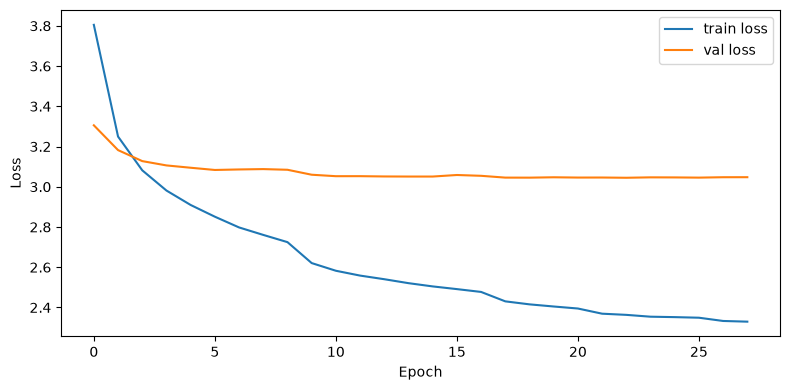

In [16]:
# 8. TRAINING
# =============================================================================
criterion = nn.CrossEntropyLoss(ignore_index=0)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5)
 
EPOCHS       = 40
PATIENCE     = 5
best_val     = float("inf")
patience_ctr = 0
train_losses, val_losses = [], []
 
for epoch in range(1, EPOCHS + 1):
    # ── Train ─────────────────────────────────────────────────────────────────
    model.train()
    running_loss = 0.0
    for img_feat, cap_seq, target in train_loader:
        img_feat = img_feat.to(DEVICE)
        cap_seq  = cap_seq.to(DEVICE)
        target   = target.to(DEVICE)
 
        optimizer.zero_grad()
        logits = model(img_feat, cap_seq)
        loss   = criterion(logits, target)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()
        running_loss += loss.item()
 
    train_loss = running_loss / len(train_loader)
 
    # ── Validate ──────────────────────────────────────────────────────────────
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for img_feat, cap_seq, target in val_loader:
            img_feat = img_feat.to(DEVICE)
            cap_seq  = cap_seq.to(DEVICE)
            target   = target.to(DEVICE)
            logits   = model(img_feat, cap_seq)
            val_loss += criterion(logits, target).item()
 
    val_loss /= len(val_loader)
    scheduler.step(val_loss)
 
    train_losses.append(train_loss)
    val_losses.append(val_loss)
 
    print(f"Epoch {epoch:2d}/{EPOCHS}  train_loss={train_loss:.4f}  val_loss={val_loss:.4f}")
 
    # ── Early stopping + checkpoint ───────────────────────────────────────────
    if val_loss < best_val:
        best_val = val_loss
        patience_ctr = 0
        torch.save(model.state_dict(), "best_model.pt")
        print(f"  ✓ Saved best model (val_loss={best_val:.4f})")
    else:
        patience_ctr += 1
        if patience_ctr >= PATIENCE:
            print(f"Early stopping at epoch {epoch}")
            break
 
# Load best weights
model.load_state_dict(torch.load("best_model.pt", map_location=DEVICE))
 
# Plot
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label="train loss")
plt.plot(val_losses,   label="val loss")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend()
plt.tight_layout(); plt.savefig("training_curves.png", dpi=120); plt.show()
 

In [ ]:
# 9. BEAM SEARCH DECODING, !Greedy search
# =============================================================================
def generate_caption_beam(model, features, word2idx, idx2word, max_length, beam_width=3): #     word2idx / idx2word → vocabulary mapping
    model.eval()
    feat      = torch.tensor(features, dtype=torch.float32).unsqueeze(0).to(DEVICE)
    start_idx = word2idx["startseq"]
    end_idx   = word2idx["endseq"]
 
    beams     = [(0.0, [start_idx])]
    completed = []
 
    with torch.no_grad():
        for _ in range(max_length):
            candidates = []
            for score, seq in beams:
                if seq[-1] == end_idx:
                    completed.append((score, seq))
                    continue
                # pre-pad
                pad_len = max_length - len(seq)
                padded  = [0] * pad_len + seq
                cap_t   = torch.tensor([padded], dtype=torch.long).to(DEVICE)
 
                logits  = model(feat, cap_t)
                probs   = torch.softmax(logits, dim=-1)[0].cpu().numpy()
                top_k   = np.argsort(probs)[-beam_width:]
 
                for idx in top_k:
                    new_score = score + np.log(probs[idx] + 1e-10)
                    candidates.append((new_score, seq + [int(idx)]))
 
            if not candidates:
                break
            candidates.sort(key=lambda x: x[0], reverse=True)
            beams = candidates[:beam_width]
 
    completed.extend(beams)
    best_seq = max(completed, key=lambda x: x[0])[1]
    words = [idx2word.get(i, "") for i in best_seq
             if i not in (start_idx, end_idx, 0)]
    return " ".join(words).strip()

In [18]:
# 10. BLEU EVALUATION
# =============================================================================
actual, predicted = [], []
smooth = SmoothingFunction().method1
 
print("Evaluating captions...")
for img, item in final_dataset.items():
    pred = generate_caption_beam(model, item["features"], word2idx, idx2word, max_length)
    refs = [cap.replace("startseq", "").replace("endseq", "").split()
            for cap in item["captions"]]
    actual.append(refs)
    predicted.append(pred.split())
 
bleu1 = corpus_bleu(actual, predicted, weights=(1,0,0,0), smoothing_function=smooth)
bleu4 = corpus_bleu(actual, predicted, weights=(.25,.25,.25,.25), smoothing_function=smooth)
print(f"BLEU-1 : {bleu1:.4f}")
print(f"BLEU-4 : {bleu4:.4f}")

Evaluating captions...
BLEU-1 : 0.5664
BLEU-4 : 0.1655


In [23]:
print(actual[0])

print("-------"*50)
print(predicted[0])

[['a', 'child', 'in', 'a', 'pink', 'dress', 'is', 'climbing', 'up', 'a', 'set', 'of', 'stairs', 'in', 'an', 'entry', 'way'], ['a', 'girl', 'going', 'into', 'a', 'wooden', 'building'], ['a', 'little', 'girl', 'climbing', 'into', 'a', 'wooden', 'playhouse'], ['a', 'little', 'girl', 'climbing', 'the', 'stairs', 'to', 'her', 'playhouse'], ['a', 'little', 'girl', 'in', 'a', 'pink', 'dress', 'going', 'into', 'a', 'wooden', 'cabin']]
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
['a', 'man', 'in', 'a', 'red', 'shirt', 'is', 'sitting', 'on', 'a', 'bench']


In [19]:
# 11. ROUGE EVALUATION
# =============================================================================
scorer = rouge_module.RougeScorer(["rouge1", "rougeL"], use_stemmer=True)
r1, rL = [], []
 
for img, item in final_dataset.items():
    pred = generate_caption_beam(model, item["features"], word2idx, idx2word, max_length)
    for cap in item["captions"]:
        ref = cap.replace("startseq","").replace("endseq","").strip()
        sc  = scorer.score(ref, pred)
        r1.append(sc["rouge1"].fmeasure)
        rL.append(sc["rougeL"].fmeasure)
 
print(f"ROUGE-1 : {np.mean(r1):.4f}")
print(f"ROUGE-L : {np.mean(rL):.4f}")
 
# Sample output
sample_img  = list(final_dataset.keys())[0]
sample_item = final_dataset[sample_img]
sample_pred = generate_caption_beam(model, sample_item["features"], word2idx, idx2word, max_length)
print(f"\nSample image     : {sample_img}")
print(f"Predicted caption: {sample_pred}")
print("Reference captions:")
for ref in sample_item["captions"]:
    print(" ", ref.replace("startseq","").replace("endseq","").strip())
 
# Save artefacts
torch.save(model.state_dict(), "image_captioning_model.pt")
with open("tokenizer.pkl", "wb") as f:
    pickle.dump({"word2idx": word2idx, "idx2word": idx2word, "max_length": max_length}, f)
print("\nAll artefacts saved.")

ROUGE-1 : 0.3232
ROUGE-L : 0.2980

Sample image     : 1000268201_693b08cb0e.jpg
Predicted caption: a man in a red shirt is sitting on a bench
Reference captions:
  a child in a pink dress is climbing up a set of stairs in an entry way
  a girl going into a wooden building
  a little girl climbing into a wooden playhouse
  a little girl climbing the stairs to her playhouse
  a little girl in a pink dress going into a wooden cabin

All artefacts saved.
